# Peminjaman buku kategori filosofi dan psikologi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import altair as alt
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Reshape, GRU, Dense, Dropout, TimeDistributed
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from bayes_opt import BayesianOptimization
from scipy.ndimage import gaussian_filter1d  

Read Dataset

In [2]:
buku_000 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_000.csv')
buku_100 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_100.csv')
buku_200 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_200.csv')
buku_300 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_300.csv')
buku_400 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_400.csv')
buku_500 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_500.csv')
buku_600 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_600.csv')
buku_700 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_700.csv')
buku_800 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_800.csv')
buku_900 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_900.csv')

buku_000['Bulan'] = pd.to_datetime(buku_000['Bulan'], format='%m/%y')
buku_100['Bulan'] = pd.to_datetime(buku_100['Bulan'], format='%m/%y')
buku_200['Bulan'] = pd.to_datetime(buku_200['Bulan'], format='%m/%y')
buku_300['Bulan'] = pd.to_datetime(buku_300['Bulan'], format='%m/%y')
buku_400['Bulan'] = pd.to_datetime(buku_400['Bulan'], format='%m/%y')
buku_500['Bulan'] = pd.to_datetime(buku_500['Bulan'], format='%m/%y')
buku_600['Bulan'] = pd.to_datetime(buku_600['Bulan'], format='%m/%y')
buku_700['Bulan'] = pd.to_datetime(buku_700['Bulan'], format='%m/%y')
buku_800['Bulan'] = pd.to_datetime(buku_800['Bulan'], format='%m/%y')
buku_900['Bulan'] = pd.to_datetime(buku_900['Bulan'], format='%m/%y')

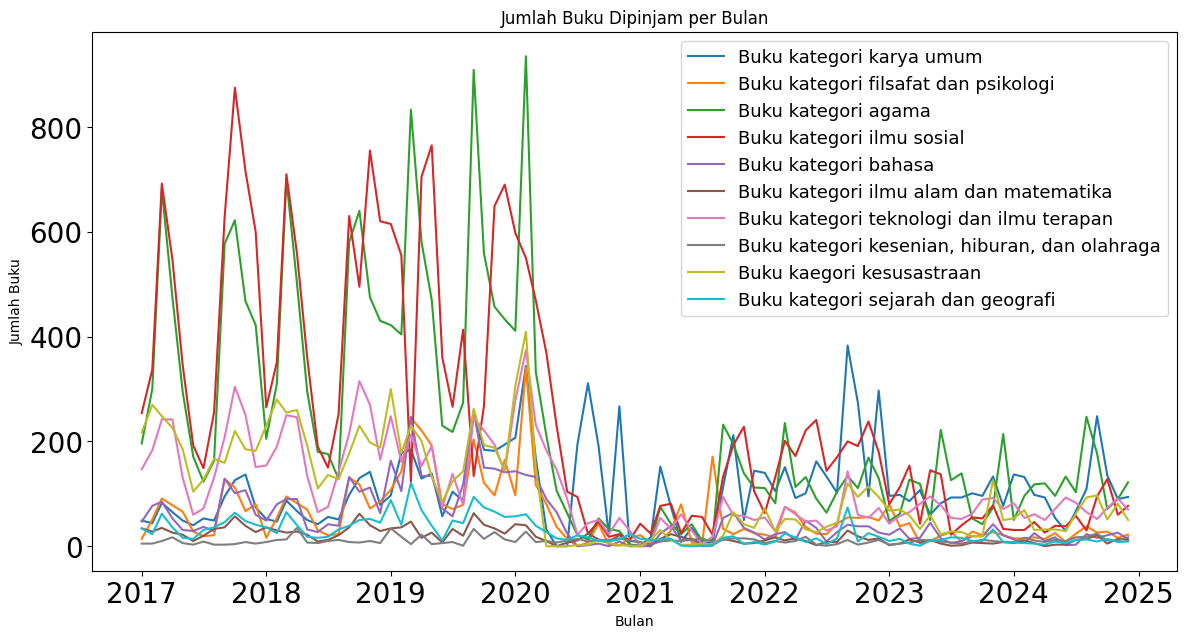

In [6]:
#make plot all book
plt.figure(figsize=(14,7))
plt.plot(buku_000['Bulan'], buku_000['Jumlah_buku_dipinjam'], label='Buku kategori karya umum')
plt.plot(buku_100['Bulan'], buku_100['Jumlah_buku_dipinjam'], label='Buku kategori filsafat dan psikologi')
plt.plot(buku_200['Bulan'], buku_200['Jumlah_buku_dipinjam'], label='Buku kategori agama')
plt.plot(buku_300['Bulan'], buku_300['Jumlah_buku_dipinjam'], label='Buku kategori ilmu sosial')
plt.plot(buku_400['Bulan'], buku_400['Jumlah_buku_dipinjam'], label='Buku kategori bahasa')
plt.plot(buku_500['Bulan'], buku_500['Jumlah_buku_dipinjam'], label='Buku kategori ilmu alam dan matematika')
plt.plot(buku_600['Bulan'], buku_600['Jumlah_buku_dipinjam'], label='Buku kategori teknologi dan ilmu terapan')
plt.plot(buku_700['Bulan'], buku_700['Jumlah_buku_dipinjam'], label='Buku kategori kesenian, hiburan, dan olahraga')
plt.plot(buku_800['Bulan'], buku_800['Jumlah_buku_dipinjam'], label='Buku kaegori kesusastraan')
plt.plot(buku_900['Bulan'], buku_900['Jumlah_buku_dipinjam'], label='Buku kategori sejarah dan geografi')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku')
plt.title('Jumlah Buku Dipinjam per Bulan')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=13)
plt.show()